# MetHyInfra - CFD Workshop 
<font size="4"> **Part 3: Tutorial case of a critical nozzle** </font> <br>
<font size="3"> "***FROM A***<em>djusting the mesh</em> ***TO*** <em>visuali</em>***Z***<em>ing the flow field</em> " </font> <br>
---
Sebastian Weiss, PTB Berlin, Germany <br>
15.06.2023

In [1]:
import numpy as np; 
import matplotlib.pyplot as plt; plt.close("all")
import matplotlib.axes as plax;


# 1. Geometry creation

## 1.1 Functions

### 1.1.1 Ideal toroidal nozzles (*Tor_ideal*)

In [2]:
################################ -- Ideal toroidal CFVNs -- ###############################################################
def Tor_ideal(l, al, nz):
    """
    Parameters
    ----------
    l : double
        nozzle length (in d)
    al : double 
        diffusor angle (in °)
    nz : int
        number of points
    """
    zc = np.sqrt(2.0**2 - (2.0-(2.5-1.0)/2)**2);
    zal = 2.0*np.sin(al*np.pi/180.0);
    ze = l;
    ntest = round((nz-5)/4);
    nz = 4*ntest + 5;
    BSz = np.linspace(0.0, ze, nz);
    BSy = np.linspace(0.0, 0.0, nz);
    for i in range(0,nz):
        if BSz[i] < zc + zal:
            BSy[i] = 5/2 - np.sqrt(2.0**2 - (BSz[i]-zc)**2);
        else:
            BSy[i] = 1/2 + (1.0-np.cos(al*np.pi/180.0))*2.0 + np.tan(al*np.pi/180.0)*(BSz[i]-(zc+zal)) ;
    BSd = int(np.round(np.median(np.where(BSy == BSy.min()))));
    return BSz, BSy, BSd
###########################################################################################################################

### 1.1.2 Ideal cylindrical nozzles (*Cyl_ideal*)

In [3]:
################################ -- Ideal cylindrical CFVNs -- ############################################################
def Cyl_ideal(l, al, nz):
    """
    Parameters
    ----------
    l : double
        nozzle length (in d)
    al : double 
        diffusor angle (in °)
    nz : int
        number of points
    """
    ze = l;
    ntest = round((nz-5)/4);
    nz = 4*ntest + 5;
    BSz = np.linspace(0.0, ze, nz);
    BSy = np.linspace(0.0, 0.0, nz);
    for i in range(0,nz):
        if BSz[i] < 1.0:
            BSy[i] = 3/2 - np.sqrt(1.0**2 - (BSz[i]-1.0)**2);
        elif BSz[i] > 2.0:
            BSy[i] = 1/2 + np.tan(al*np.pi/180.0)*(BSz[i]-2.0) ;
        else:
            BSy[i] = 1/2;
    BSd = int(np.round(np.median(np.where(BSy == BSy.min()))));        
    return BSz, BSy, BSd
###########################################################################################################################

### 1.1.3 Measured nozzles (*Meas_CFVN*)

In [4]:
################################ -- Measured CFVNs -- #####################################################################
def Meas_CFVN(meas_data, NType, l, n_in, n_out):
    """
    Parameters
    ----------
    meas_data : str
        file containing measured contour data (list of z and y positions, tab-separated)
    NType : int
        nozzle type (0 if cylindrical, 1 if toroidal)
    l : double
        nozzle length (in d)
    n_in : double 
        point index for inlet circle
    n_out : int
        point index for outlet slope
    """
    ## Measurement input
    BSSMeas = np.loadtxt(meas_data, delimiter='\t', skiprows = 1);
    Shift_cyl = 1.5;
    Shift_tor = np.sqrt(39)/4;
    # NType = 0 --> Cyl; NType = 1 --> Tor;
    BSzMeas = BSSMeas[:,0] + (1 - NType) * Shift_cyl + NType * Shift_tor;
    BSyMeas = BSSMeas[:,1];
    BSdMeas = int(np.round(np.median(np.where(BSyMeas == BSyMeas.min()))));
    ze = l;
    nz = len(BSzMeas)*l/(BSzMeas[len(BSzMeas)-1]-BSzMeas[0]); 
    ntest = round((nz-5)/4);
    nz = 4*ntest + 5;

    ## Inlet extension
    nz1 = round(nz*(BSzMeas[0] - 0.0)/l) + 1;
    BSz1 = np.linspace(0.0, BSzMeas[0], nz1);
    BSy1 = np.linspace(0.0, 0.0, nz1);    
    
    zn_in = BSzMeas[0:n_in];
    yn_in = BSyMeas[0:n_in];
    
    ## Solving Linear System (A^T*Ax = A^Tb) on n points
    A = np.ones((3, 3));
    b = np.ones(3);
    
    A[0,0] = sum(zn_in**2); A[0,1] = sum(zn_in*yn_in); A[0,2] = sum(zn_in);
    A[1,0] = sum(zn_in*yn_in); A[1,1] = sum(yn_in**2); A[1,2] = sum(yn_in);
    A[2,0] = sum(zn_in); A[2,1] = sum(yn_in); A[2,2] = n_in;
    
    b[0] = sum(zn_in*(zn_in**2 + yn_in**2));
    b[1] = sum(yn_in*(zn_in**2 + yn_in**2));
    b[2] = sum(zn_in**2 + yn_in**2);
    
    A_T = A.transpose();
    A_new = np.matmul(A_T,A);
    b_new = np.matmul(A_T,b);
    n_opt = np.linalg.solve(A_new,b_new);

    pz = n_opt[0]/2;
    py = n_opt[1]/2;
    R = np.sqrt(n_opt[2] + (n_opt[0]**2 + n_opt[1]**2)/4);
    
    BSy1 = py - np.sqrt(R**2 - (BSz1 - pz)**2);
    n_nan = np.count_nonzero(np.isnan(BSy1));
    if (n_nan > 0):
        BSzmax = BSz1[-1];
        BSy1 = BSy1[n_nan:];
        BSz1 = BSz1[0:-n_nan];
        delta = BSzmax - BSz1[-1];
        BSzMeas = BSzMeas - delta;
        nz1 = nz1 - n_nan;

    ## Outlet extension
    nz2 = nz - len(BSzMeas) - nz1 + 2;
    BSz2 = np.linspace(BSzMeas[-1], ze, nz2);
    BSy2 = np.linspace(0.0, 0.0, nz2);
    
    m = (BSyMeas[-(n_out+1)] - BSyMeas[-(n_out+2)])/(BSzMeas[-(n_out+1)] - BSzMeas[-(n_out+2)]);
    n = BSyMeas[-1] - m * BSzMeas[-1];
    BSy2 = m * BSz2 + n;

    ## Creation of full BS vectors
    BSz = np.concatenate((BSz1[0:-1], BSzMeas, BSz2[1:]), axis=None);
    BSy = np.concatenate((BSy1[0:-1], BSyMeas, BSy2[1:]), axis=None);
    BSd = int(np.round(np.median(np.where(BSy == BSy.min()))));
    return BSz, BSy, BSd, BSzMeas, BSyMeas
###########################################################################################################################

### 1.1.4 Creation of geometry file (*create_geometry_file*)

In [5]:
################################ -- Creation of geometry file -- ##########################################################
def create_geometry_file(name, BSz, BSy, BSd): 
    """
    Parameters
    ----------
    name : str
        name of output file
    BSz : array 
        vector of axial nozzle coordinates
    BSy : array
        vector of radial nozzle coordinates
    BSd : int
        index of throat diameter position
    """
    f = open(name, 'w');
    f.write('BSz ( ');
    np.savetxt(f, BSz, fmt='%.6f', newline = ' ');
    f.write(' ); \n \nBSy ( ');
    np.savetxt(f, BSy, fmt='%.6f', newline = ' ');
    f.write(' ); \n \nBSd ' + str(BSd) + ';');
    f.close();
########################################################################################################################   

## 1.2 Nozzle contour creation

### 1.2.1 Creation of ideal toroidal nozzle

In [6]:
### Input parameters ###
l = 9.0;   # nozzle length
al = 4.0;  # diffusor angle
nz = 1000; # number of contour points

### Nozzle contour (Ideal toroidal nozzle) ###
zTor, yTor, dTor = Tor_ideal(l, al, nz);  

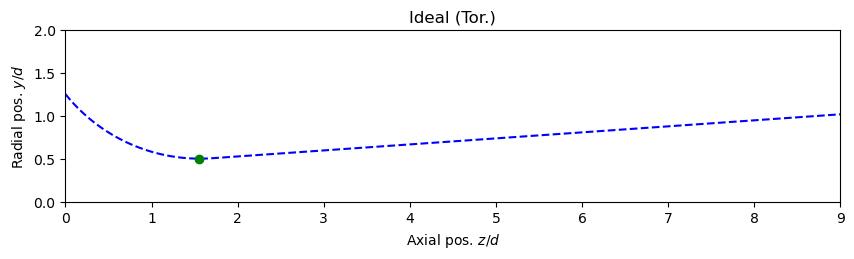

In [7]:
### Visualization ###
plt.figure().set_figwidth(10);
plt.plot(zTor, yTor,'b--');   # Plot of ideal contour (tor. type)
plt.plot(zTor[dTor], yTor[dTor],'go');
ax = plt.gca();
ax.set_aspect('equal', adjustable='box');
plt.xlim([0, l]);
plt.ylim([0, 2]);
plt.xlabel('Axial pos. $z/d$');
plt.ylabel('Radial pos. $y/d$');
plt.title('Ideal (Tor.)');
plt.savefig('./Output/1-2-1_Ideal_Tor.png',dpi=600, facecolor='w');

In [8]:
### Creation of geometry file ###
create_geometry_file('./Output/Ideal_Tor.out', zTor, yTor, dTor);

### 1.2.2 Creation of ideal cylindrical nozzle

In [9]:
### Input parameters ###
l = 9.0;   # nozzle length
al = 4.0;  # diffusor angle
nz = 1000; # number of contour points

### Nozzle contour (Ideal cylindrical nozzle) ###
zCyl, yCyl, dCyl = Cyl_ideal(l, al, nz); 

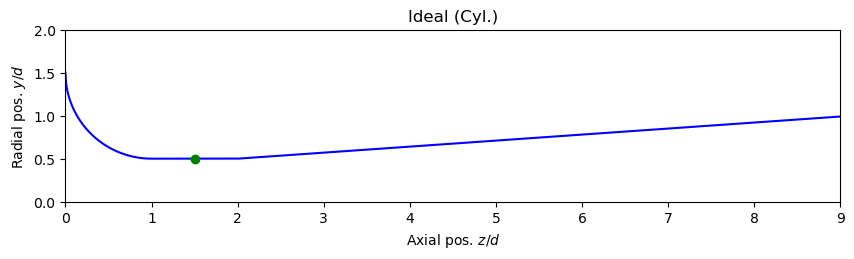

In [10]:
### Visualization ###
plt.figure().set_figwidth(10);
plt.plot(zCyl, yCyl,'b'); # Plot of ideal contour (cyl. type)
plt.plot(zCyl[dCyl], yCyl[dCyl],'go');
ax = plt.gca();
ax.set_aspect('equal', adjustable='box');
plt.xlim([0, l]);
plt.ylim([0, 2]);
plt.xlabel('Axial pos. $z/d$');
plt.ylabel('Radial pos. $y/d$');
plt.title('Ideal (Cyl.)');
plt.savefig('./Output/1-2-2_Ideal_Cyl.png',dpi=600, facecolor='w');

In [11]:
### Creation of geometry file ###
create_geometry_file('./Output/Ideal_Cyl.out', zCyl, yCyl, dCyl);

### 1.2.3 Creation of meas. cylindrical nozzle

In [12]:
### Input parameters ###
meas_data = './Input/Cyl_D1_meas.txt'; # measured contour data
NType = 0;  # nozzle type (Cyl. type = 0, Tor. type = 1)
l = 9.0;    # nozzle length
n_in = 40;  # point index of inlet circle
n_out = 25; # point index of outlet slope

### Nozzle contour (Meas. cylindrical nozzle) ###
zMeas, yMeas, dMeas, zMeasRaw, yMeasRaw  = Meas_CFVN(meas_data, NType, l, n_in, n_out); 

C:\Users\weiss08\AppData\Local\Temp\ipykernel_5600\1793825738.py:45: RuntimeWarning: invalid value encountered in sqrt
  BSy1 = py - np.sqrt(R**2 - (BSz1 - pz)**2);


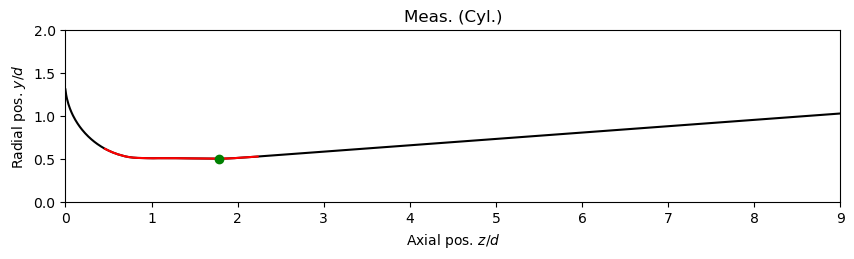

In [13]:
### Visualization ###
plt.figure().set_figwidth(10);
plt.plot(zMeas, yMeas,'k'); # Plot of meas. contour (cyl. type)
plt.plot(zMeasRaw, yMeasRaw,'r'); # Plot of raw meas. contour (cyl. type)
plt.plot(zMeas[dMeas], yMeas[dMeas],'go');
ax = plt.gca();
ax.set_aspect('equal', adjustable='box');
plt.xlim([0, l]);
plt.ylim([0, 2]);
plt.xlabel('Axial pos. $z/d$');
plt.ylabel('Radial pos. $y/d$');
plt.title('Meas. (Cyl.)');
plt.savefig('./Output/1-2-3_Meas_Cyl.png',dpi=600, facecolor='w');

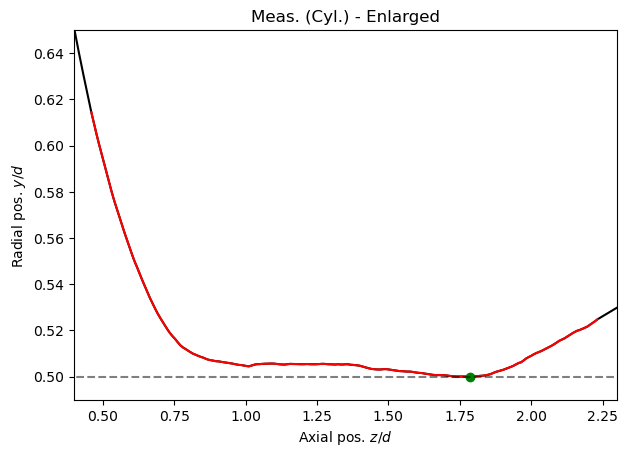

In [14]:
### Visualization ###
plt.figure().set_figwidth(7);
plt.plot(zMeas, yMeas,'k'); # Plot of meas. contour (cyl. type)
plt.plot(zMeasRaw, yMeasRaw,'r'); # Plot of raw meas. contour (cyl. type)
plt.plot(zMeas[dMeas], yMeas[dMeas],'go');
plt.plot([0,9],[0.5, 0.5], 'k--', alpha = 0.5);
ax = plt.gca();
#ax.set_aspect('equal', adjustable='box');
plt.xlim([0.4, 2.3]);
plt.ylim([0.49, 0.65]);
plt.xlabel('Axial pos. $z/d$');
plt.ylabel('Radial pos. $y/d$');
plt.title('Meas. (Cyl.) - Enlarged');
plt.savefig('./Output/1-2-3_Meas_Cyl_Enlarged.png',dpi=600, facecolor='w');

In [15]:
### Create geometry file ###
create_geometry_file('./Output/Meas_Cyl.out', zMeas, yMeas, dMeas);

# 5.a) Residuals

In [16]:
### Load data ###
path_res = './Tutorials/Meas_Cyl/logs/';
res_e = np.loadtxt(path_res + 'e_1', delimiter='\t', skiprows = 0);
res_k = np.loadtxt(path_res + 'k_0', delimiter='\t', skiprows = 0);
res_o = np.loadtxt(path_res + 'omega_0', delimiter='\t', skiprows = 0);
res_p = np.loadtxt(path_res + 'p_1', delimiter='\t', skiprows = 0);
res_Uy = np.loadtxt(path_res + 'Uy_1', delimiter='\t', skiprows = 0);
res_Uz = np.loadtxt(path_res + 'Uz_1', delimiter='\t', skiprows = 0);

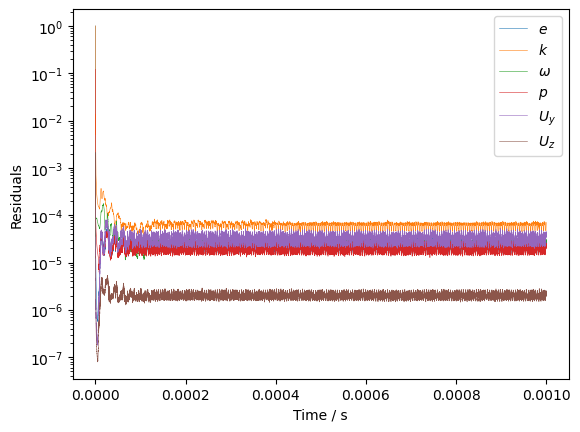

In [17]:
### Plot data ###
plt.semilogy(res_e[:,0], res_e[:,1], label = '$e$', linewidth = 0.4);
plt.semilogy(res_k[:,0], res_k[:,1], label = '$k$', linewidth = 0.4);
plt.semilogy(res_o[:,0], res_o[:,1], label = '$\omega$', linewidth = 0.4);
plt.semilogy(res_p[:,0], res_p[:,1], label = '$p$', linewidth = 0.4);
plt.semilogy(res_Uy[:,0], res_Uy[:,1], label = '$U_y$', linewidth = 0.4);
plt.semilogy(res_Uz[:,0], res_Uz[:,1], label = '$U_z$', linewidth = 0.4);
plt.xlabel('Time / s');
plt.ylabel('Residuals');
plt.legend();

plt.savefig('./Output/5-a_Residuals.png',dpi=600, facecolor='w');

# 5.b) Mass flow rate

In [18]:
### Load data ###
path_mass = './Tutorials/Meas_Cyl/postProcessing/massFlowRate/0/';
mass = np.loadtxt(path_mass + 'surfaceFieldValue.dat', delimiter='\t', skiprows = 5);

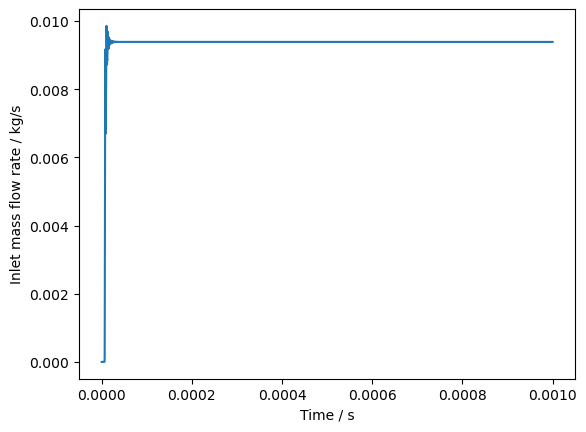

In [19]:
### Plot data ###
alpha = 5;

### MFR ###
plt.plot(mass[:,0], -360/alpha * mass[:,1], 'tab:blue');
plt.xlabel('Time / s');
plt.ylabel('Inlet mass flow rate / kg/s');

plt.savefig('./Output/5-b_MFR.png',dpi=600, facecolor='w');

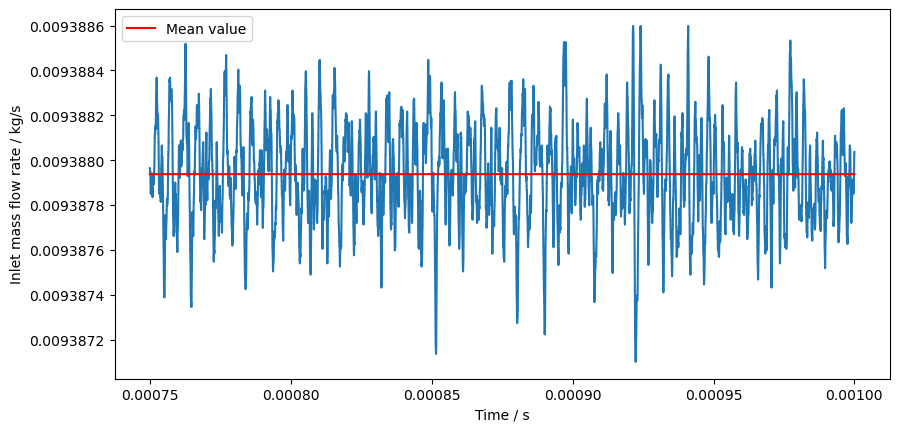

In [20]:
### MFR - Zoom ###
tstart = 300000;
plt.figure().set_figwidth(10);

m_CFD = np.mean(-360/alpha*mass[tstart:,1]); # Mean value

plt.plot(mass[tstart:,0], -360/alpha*mass[tstart:,1], 'tab:blue');
plt.plot(mass[tstart:,0], m_CFD*np.ones(len(mass[tstart:,1])), 'r', label = 'Mean value');
plt.xlabel('Time / s');
plt.ylabel('Inlet mass flow rate / kg/s');
plt.legend();

plt.savefig('./Output/5-b_MFR_zoom.png',dpi=600, facecolor='w');

# 6. Discharge coefficient

In [21]:
### Calculate CD value ###

# Input
kap = 1.4;
Cstar_i = np.sqrt(kap * (2/(kap+1))**((kap+1)/(kap-1)));
Cstar_r = 0.67155;
d = 0.001;
p0 = 200*10**5;
T0 = 300;
R = 8.3144626;
M = 0.002016;
R_M = R/M;

# Area of CFD model
A_CFD = 360 / alpha * np.sin(0.5*alpha*np.pi/180) * np.cos(0.5*alpha*np.pi/180) * 1/4 * d**2;

# Mass flow rates (Theory)
m_th_r = Cstar_r * A_CFD * p0 / np.sqrt(R_M * T0);
m_th_i = Cstar_i * A_CFD * p0 / np.sqrt(R_M * T0);

# Discharge coefficients
CD_r = m_CFD / m_th_r;
CD_i = m_CFD / m_th_i;

# Display
print('Mass flow rate:');
print('\t CFD: \t\t' + str(m_CFD) + ' kg/s');
print('\t Theory real: \t' + str(m_th_r) + ' kg/s');
print('\t Theory ideal: \t' + str(m_th_i) + ' kg/s');
print('\n')
print('Discharge coefficient:');
print('\t Real: \t\t' + str(CD_r));
print('\t Ideal: \t' + str(CD_i));

Mass flow rate:
	 CFD: 		0.009387937810511999 kg/s
	 Theory real: 	0.00947140508235179 kg/s
	 Theory ideal: 	0.009657313671324285 kg/s


Discharge coefficient:
	 Real: 		0.9911874456731539
	 Ideal: 	0.9721065432914174
